# GIAI ĐOẠN 4A: TIỀN XỬ LÝ ẢNH

### Mục tiêu:
- Xử lý toàn bộ ảnh train/valid với pipeline tiền xử lý từ Giai đoạn 3
- Tạo dataset structure đúng với train/val split
- Tạo data.yaml với class names đúng (bus, bikes, cars, pedestrian, truck)

### Quy trình:
1. Import các hàm preprocessing từ Giai đoạn 3
2. Tìm và xác định dataset Fisheye8K-7
3. Tiền xử lý ảnh train và valid với pipeline:
   - ~~Khử méo fisheye (undistort)~~ **TẮT** - vì làm vật thể bị lệch
   - Tăng tương phản (CLAHE)
   - Tăng cường dữ liệu (Brightness/Contrast/Gamma)
   - Làm sắc nét (Sharpen)
   - Letterbox resize về 640x640
   - **Tự động điều chỉnh labels** cho letterbox resize
4. Xem so sánh ảnh trước và sau khi xử lý
5. Tạo data.yaml với class names đúng cho YOLO training

### ⚠️ Lưu ý:
- **Undistort fisheye đã được TẮT** vì làm ảnh từ hình tròn → chữ nhật, khiến vật thể bị lệch
- **Labels sẽ được tự động điều chỉnh** cho letterbox resize
- Model sẽ học trực tiếp trên ảnh fisheye (không cần undistort)


In [4]:
# Import các thư viện cần thiết
import os
import shutil
import yaml
import cv2
import numpy as np
import albumentations as A
from pathlib import Path
from tqdm import tqdm
import glob

print("✅ Đã import các thư viện cơ bản")

# ==============================================================================
# SAO CHÉP CÁC HÀM CẦN THIẾT TỪ GIAI ĐOẠN 3
# (Không thể import trực tiếp từ .ipynb, nên copy code vào đây)
# ==============================================================================

def check_image_validity(img, img_path=None):
    """Kiểm tra tính hợp lệ của ảnh với các edge cases đầy đủ."""
    try:
        if img is None and img_path:
            if not os.path.exists(img_path):
                return False, f"Ảnh không tồn tại: {img_path}"
            valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp')
            if not img_path.lower().endswith(valid_extensions):
                return False, f"Định dạng file không hỗ trợ: {img_path}"
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            if img is None:
                return False, f"Không đọc được ảnh (có thể file bị hỏng): {img_path}"
        if img is None:
            return False, "Ảnh là None."
        if img.size == 0:
            return False, "Ảnh rỗng"
        if len(img.shape) not in [2, 3]:
            return False, f"Định dạng không hợp lệ: shape {img.shape}"
        h, w = img.shape[:2]
        if h < 10 or w < 10:
            return False, f"Ảnh quá nhỏ: {w}x{h} (tối thiểu 10x10)"
        if h > 50000 or w > 50000:
            return False, f"Ảnh quá lớn: {w}x{h} (tối đa 50000x50000)"
        if len(img.shape) == 3:
            if img.shape[2] not in [1, 3, 4]:
                return False, f"Kênh màu không hợp lệ: {img.shape[2]}"
        if np.any(np.isnan(img)) or np.any(np.isinf(img)):
            return False, "Ảnh chứa giá trị NaN hoặc Inf"
        if img.dtype not in [np.uint8, np.uint16, np.float32, np.float64]:
            return False, f"Kiểu dữ liệu không hợp lệ: {img.dtype}"
        return True, "Ảnh hợp lệ."
    except Exception as e:
        return False, f"Lỗi kiểm tra: {str(e)}"

def analyze_image_properties(img):
    """Phân tích đặc tính ảnh và đưa ra gợi ý xử lý."""
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
        mean_brightness = np.mean(gray)
        is_too_dark = mean_brightness < 50
        is_too_bright = mean_brightness > 200
        laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        is_blurry = laplacian_var < 100
        if len(img.shape) == 3:
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        else:
            lab = cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), cv2.COLOR_BGR2LAB)
        l, _, _ = cv2.split(lab)
        contrast = np.std(l)
        is_low_contrast = contrast < 30
        is_low_saturation = False
        if len(img.shape) == 3 and img.shape[2] == 3:
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            saturation = hsv[:, :, 1].mean()
            is_low_saturation = saturation < 50
        suggestions = {
            'apply_contrast': is_too_dark or is_too_bright or is_low_contrast,
            'apply_sharpen': is_blurry,
            'apply_augmentation': is_low_saturation or is_low_contrast,
            'issues': []
        }
        if is_too_dark:
            suggestions['issues'].append(f"Quá tối (sáng: {mean_brightness:.1f})")
        if is_too_bright:
            suggestions['issues'].append(f"Quá sáng (sáng: {mean_brightness:.1f})")
        if is_blurry:
            suggestions['issues'].append(f"Mờ (Laplacian: {laplacian_var:.1f})")
        if is_low_contrast:
            suggestions['issues'].append(f"Tương phản thấp (std: {contrast:.1f})")
        if is_low_saturation:
            suggestions['issues'].append(f"Bão hòa thấp (sat: {saturation:.1f})")
        return suggestions
    except Exception as e:
        return {'issues': [f"Lỗi phân tích: {str(e)}"], 'apply_contrast': False, 'apply_sharpen': False, 'apply_augmentation': False}

def letterbox(img, new_shape=(640, 640), color=(114, 114, 114)):
    """Resize ảnh mà giữ tỷ lệ khung hình, thêm padding nếu cần."""
    try:
        shape = img.shape[:2]
        if shape[0] <= 0 or shape[1] <= 0:
            return img.copy()
        r = min(new_shape[0] / max(shape[0], 1), new_shape[1] / max(shape[1], 1))
        new_unpad = (int(round(shape[1] * r)), int(round(shape[0] * r)))
        new_unpad = (max(1, new_unpad[0]), max(1, new_unpad[1]))
        dw, dh = new_shape[1] - new_unpad[0], new_shape[0] - new_unpad[1]
        dw /= 2
        dh /= 2
        if shape[::-1] != new_unpad:
            img = cv2.resize(img, new_unpad, interpolation=cv2.INTER_LINEAR)
        top, bottom = max(0, int(round(dh - 0.1))), max(0, int(round(dh + 0.1)))
        left, right = max(0, int(round(dw - 0.1))), max(0, int(round(dw + 0.1)))
        return cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    except Exception as e:
        return img.copy()

def get_letterbox_transform_info(old_width, old_height, new_shape=(640, 640)):
    """
    Tính toán transformation info cho letterbox resize.
    
    Args:
        old_width: Chiều rộng ảnh gốc
        old_height: Chiều cao ảnh gốc
        new_shape: Kích thước ảnh mới (height, width)
    
    Returns:
        Dict với các thông tin: scale, pad_left, pad_top, scaled_width, scaled_height
    """
    try:
        if old_width <= 0 or old_height <= 0:
            return None
        
        scale = min(new_shape[0] / old_height, new_shape[1] / old_width)
        scaled_width = old_width * scale
        scaled_height = old_height * scale
        pad_left = (new_shape[1] - scaled_width) / 2
        pad_top = (new_shape[0] - scaled_height) / 2
        
        return {
            'scale': scale,
            'pad_left': pad_left,
            'pad_top': pad_top,
            'scaled_width': scaled_width,
            'scaled_height': scaled_height,
            'new_width': new_shape[1],
            'new_height': new_shape[0],
            'old_width': old_width,
            'old_height': old_height
        }
    except Exception:
        return None

def adjust_labels_for_letterbox(labels_str, old_width, old_height, new_size=640):
    """
    Điều chỉnh tọa độ labels (normalized 0-1) theo letterbox transformation.
    
    Args:
        labels_str: String chứa labels (format YOLO: class x_center y_center width height)
        old_width: Chiều rộng ảnh gốc
        old_height: Chiều cao ảnh gốc
        new_size: Kích thước ảnh mới (640x640)
    
    Returns:
        String labels đã điều chỉnh
    """
    if not labels_str or not labels_str.strip():
        return labels_str
    
    # Tính letterbox transformation
    transform_info = get_letterbox_transform_info(old_width, old_height, (new_size, new_size))
    if transform_info is None:
        return labels_str
    
    scale = transform_info['scale']
    pad_left = transform_info['pad_left']
    pad_top = transform_info['pad_top']
    
    adjusted_lines = []
    for line in labels_str.strip().split('\n'):
        if not line.strip():
            continue
        
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        
        cls = parts[0]
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])
        
        # Chuyển từ normalized sang pixel (ảnh gốc)
        x_center_px = x_center * old_width
        y_center_px = y_center * old_height
        width_px = width * old_width
        height_px = height * old_height
        
        # Áp dụng scale
        x_center_scaled = x_center_px * scale
        y_center_scaled = y_center_px * scale
        width_scaled = width_px * scale
        height_scaled = height_px * scale
        
        # Áp dụng padding
        x_center_final = x_center_scaled + pad_left
        y_center_final = y_center_scaled + pad_top
        
        # Chuyển về normalized (ảnh mới)
        x_center_new = x_center_final / new_size
        y_center_new = y_center_final / new_size
        width_new = width_scaled / new_size
        height_new = height_scaled / new_size
        
        # Clamp về [0, 1]
        x_center_new = max(0, min(1, x_center_new))
        y_center_new = max(0, min(1, y_center_new))
        width_new = max(0, min(1, width_new))
        height_new = max(0, min(1, height_new))
        
        adjusted_lines.append(f"{cls} {x_center_new:.6f} {y_center_new:.6f} {width_new:.6f} {height_new:.6f}")
    
    return '\n'.join(adjusted_lines)

def load_fisheye_params():
    """Tải tham số hiệu chỉnh Fisheye camera."""
    K = np.array([[1000, 0, 960], [0, 1000, 540], [0, 0, 1]], dtype=np.float32)
    D = np.array([0.1, 0.01, 0.001, 0.0001], dtype=np.float32)
    return K, D

def undistort_fisheye(img, K, D):
    """Khử méo fisheye cho ảnh với xử lý lỗi đầy đủ."""
    try:
        h, w = img.shape[:2]
        if h < 20 or w < 20:
            return img.copy()
        if K.shape != (3, 3) or D.shape != (4,):
            return img.copy()
        new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(K, D, (w, h), np.eye(3))
        map1, map2 = cv2.fisheye.initUndistortRectifyMap(K, D, np.eye(3), new_K, (w, h), cv2.CV_16SC2)
        return cv2.remap(img, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    except Exception:
        return img.copy()

def get_undistort_maps(K, D, width, height):
    """
    Tạo mapping functions cho undistort fisheye.
    Trả về map1, map2 để có thể dùng cho điều chỉnh labels.
    """
    try:
        if width < 20 or height < 20:
            return None, None
        if K.shape != (3, 3) or D.shape != (4,):
            return None, None
        new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(K, D, (width, height), np.eye(3))
        map1, map2 = cv2.fisheye.initUndistortRectifyMap(K, D, np.eye(3), new_K, (width, height), cv2.CV_16SC2)
        return map1, map2
    except Exception:
        return None, None

def adjust_labels_for_undistort(labels_str, map1, map2, width, height):
    """
    Điều chỉnh labels sau khi undistort fisheye.
    Sử dụng inverse mapping để tìm tọa độ gốc trước khi undistort.
    
    Args:
        labels_str: String chứa labels (format YOLO)
        map1, map2: Mapping functions từ initUndistortRectifyMap
        width: Chiều rộng ảnh sau undistort
        height: Chiều cao ảnh sau undistort
    
    Returns:
        String labels đã điều chỉnh
    """
    if not labels_str or not labels_str.strip() or map1 is None or map2 is None:
        return labels_str
    
    # Tạo inverse mapping: tìm tọa độ gốc (fisheye) từ tọa độ undistorted
    # Note: map1, map2 là forward mapping (fisheye -> undistort)
    # Chúng ta cần ngược lại: undistort -> fisheye
    # Cách đơn giản: tạo reverse lookup table
    
    adjusted_lines = []
    for line in labels_str.strip().split('\n'):
        if not line.strip():
            continue
        
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        
        cls = parts[0]
        x_center = float(parts[1])
        y_center = float(parts[2])
        width_norm = float(parts[3])
        height_norm = float(parts[4])
        
        # Chuyển từ normalized sang pixel (ảnh sau undistort)
        x_center_px = x_center * width
        y_center_px = y_center * height
        width_px = width_norm * width
        height_px = height_norm * height
        
        # Tính 4 góc của bounding box
        x1 = x_center_px - width_px / 2
        y1 = y_center_px - height_px / 2
        x2 = x_center_px + width_px / 2
        y2 = y_center_px + height_px / 2
        
        # Lấy tọa độ gốc (trước undistort) từ map
        # map1, map2 chứa tọa độ gốc (fisheye) cho mỗi pixel trong ảnh undistorted
        # Chúng ta cần lấy giá trị từ map tại vị trí (x, y) của bounding box
        
        # Lấy tọa độ gốc cho center và corners
        try:
            # Clamp coordinates
            x1_int = max(0, min(int(x1), width - 1))
            y1_int = max(0, min(int(y1), height - 1))
            x2_int = max(0, min(int(x2), width - 1))
            y2_int = max(0, min(int(y2), height - 1))
            center_x_int = max(0, min(int(x_center_px), width - 1))
            center_y_int = max(0, min(int(y_center_px), height - 1))
            
            # Lấy tọa độ gốc từ map (map chứa tọa độ gốc)
            # map1, map2 là CV_16SC2 format: (x, y) = (map1[y, x] & 0xFFFF, map1[y, x] >> 16)
            # Hoặc đơn giản hơn: dùng map1[y, x] và map2[y, x] trực tiếp
            # Nhưng map1, map2 là CV_16SC2 nên cần convert
            
            # Cách đơn giản: Tạo reverse mapping bằng cách sample một số điểm
            # và tính bounding box mới
            sample_points = [
                (x1_int, y1_int),  # Top-left
                (x2_int, y1_int),  # Top-right
                (x1_int, y2_int),  # Bottom-left
                (x2_int, y2_int),  # Bottom-right
                (center_x_int, center_y_int)  # Center
            ]
            
            orig_coords = []
            for px, py in sample_points:
                if 0 <= py < height and 0 <= px < width:
                    # map1, map2 lưu tọa độ gốc (fisheye)
                    # Đọc từ map
                    orig_x = map1[py, px] if map1 is not None else px
                    orig_y = map2[py, px] if map2 is not None else py
                    
                    # Nếu map là CV_16SC2, cần convert
                    if map1.dtype == np.int16:
                        # Có thể cần xử lý khác
                        orig_x = float(orig_x)
                        orig_y = float(orig_y)
                    
                    orig_coords.append((orig_x, orig_y))
            
            if len(orig_coords) >= 3:
                # Tính bounding box từ các điểm gốc
                orig_x_coords = [c[0] for c in orig_coords]
                orig_y_coords = [c[1] for c in orig_coords]
                
                orig_x_min = min(orig_x_coords)
                orig_x_max = max(orig_x_coords)
                orig_y_min = min(orig_y_coords)
                orig_y_max = max(orig_y_coords)
                
                # Tính center và size
                orig_x_center = (orig_x_min + orig_x_max) / 2
                orig_y_center = (orig_y_min + orig_y_max) / 2
                orig_width = orig_x_max - orig_x_min
                orig_height = orig_y_max - orig_y_min
                
                # Chuyển về normalized (ảnh gốc có cùng kích thước với undistort)
                # Thực tế, ảnh sau undistort có thể có kích thước khác
                # Nhưng trong trường hợp này, chúng ta giả sử cùng kích thước
                orig_x_center_norm = orig_x_center / width
                orig_y_center_norm = orig_y_center / height
                orig_width_norm = orig_width / width
                orig_height_norm = orig_height / height
                
                # Clamp
                orig_x_center_norm = max(0, min(1, orig_x_center_norm))
                orig_y_center_norm = max(0, min(1, orig_y_center_norm))
                orig_width_norm = max(0, min(1, orig_width_norm))
                orig_height_norm = max(0, min(1, orig_height_norm))
                
                adjusted_lines.append(f"{cls} {orig_x_center_norm:.6f} {orig_y_center_norm:.6f} {orig_width_norm:.6f} {orig_height_norm:.6f}")
            else:
                # Fallback: giữ nguyên nếu không tính được
                adjusted_lines.append(line)
        except Exception as e:
            # Fallback: giữ nguyên nếu có lỗi
            adjusted_lines.append(line)
    
    return '\n'.join(adjusted_lines)

def enhance_contrast(img):
    """Tăng cường độ tương phản bằng CLAHE với xử lý lỗi."""
    try:
        h, w = img.shape[:2]
        if h < 8 or w < 8:
            return img.copy()
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        tile_size = min(8, h // 4, w // 4)
        tile_size = max(2, tile_size)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(tile_size, tile_size))
        cl = clahe.apply(l)
        limg = cv2.merge((cl, a, b))
        return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    except Exception:
        return img.copy()

def sharpen_image(img):
    """Làm sắc nét ảnh bằng kernel filter với xử lý lỗi."""
    try:
        h, w = img.shape[:2]
        if h < 3 or w < 3:
            return img.copy()
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
        result = cv2.filter2D(img, -1, kernel)
        return np.clip(result, 0, 255).astype(np.uint8)
    except Exception:
        return img.copy()

def augment_image_photometric(img):
    """Tăng cường dữ liệu ảnh (photometric augmentation) với xử lý lỗi."""
    try:
        h, w = img.shape[:2]
        if h < 1 or w < 1:
            return img.copy()
        transform = A.Compose([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.RandomGamma(gamma_limit=(80, 120), p=0.5)
        ])
        result = transform(image=img)['image']
        if result.dtype != np.uint8:
            result = np.clip(result, 0, 255).astype(np.uint8)
        return result
    except Exception:
        return img.copy()

def ultimate_preprocess_pipeline(image_path=None, img=None, is_fisheye=None, 
                                K_fisheye=None, D_fisheye=None,
                                fix_contrast=False, apply_augmentation=False, 
                                apply_sharpen=False, verbose=False):
    """Pipeline tiền xử lý ảnh tổng hợp với xử lý edge cases đầy đủ."""
    try:
        is_valid, error_msg = check_image_validity(img, image_path)
        if not is_valid:
            if verbose:
                print(f"❌ Lỗi xử lý: {error_msg}")
            return None
        if img is None:
            img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
            if img is None:
                img = cv2.imread(image_path, cv2.IMREAD_COLOR)
                if img is None:
                    if verbose:
                        print(f"❌ Không thể đọc ảnh từ: {image_path}")
                    return None
        processed_img = img.copy()
        try:
            if len(processed_img.shape) == 2:
                processed_img = cv2.cvtColor(processed_img, cv2.COLOR_GRAY2BGR)
            elif len(processed_img.shape) == 3:
                if processed_img.shape[2] == 1:
                    processed_img = cv2.cvtColor(processed_img, cv2.COLOR_GRAY2BGR)
                elif processed_img.shape[2] == 4:
                    processed_img = cv2.cvtColor(processed_img, cv2.COLOR_BGRA2BGR)
                elif processed_img.shape[2] != 3:
                    processed_img = processed_img[:, :, :3]
        except cv2.error:
            return None
        if processed_img.dtype != np.uint8:
            if processed_img.dtype in [np.float32, np.float64]:
                if processed_img.max() <= 1.0:
                    processed_img = (processed_img * 255).astype(np.uint8)
                else:
                    processed_img = np.clip(processed_img, 0, 255).astype(np.uint8)
            else:
                processed_img = processed_img.astype(np.uint8)
        try:
            properties = analyze_image_properties(processed_img)
        except Exception:
            properties = {'apply_contrast': False, 'apply_sharpen': False, 'apply_augmentation': False, 'issues': []}
        if properties['issues'] and verbose:
            print(f"⚠️ Phân tích: {', '.join(properties['issues'])}")
        final_fix_contrast = fix_contrast or properties['apply_contrast']
        final_apply_augmentation = apply_augmentation or properties['apply_augmentation']
        final_apply_sharpen = apply_sharpen or properties['apply_sharpen']
        if final_apply_augmentation:
            processed_img = augment_image_photometric(processed_img)
        if is_fisheye and K_fisheye is not None and D_fisheye is not None:
            processed_img = undistort_fisheye(processed_img, K_fisheye, D_fisheye)
        if final_fix_contrast:
            processed_img = enhance_contrast(processed_img)
        if final_apply_sharpen:
            processed_img = sharpen_image(processed_img)
        result = letterbox(processed_img, new_shape=(640, 640))
        if result is None or result.size == 0:
            return None
        return result
    except Exception as e:
        if verbose:
            print(f"❌ Lỗi nghiêm trọng trong pipeline: {e}")
        return None

print("✅ Đã định nghĩa tất cả các hàm preprocessing từ Giai đoạn 3")


✅ Đã import các thư viện cơ bản
✅ Đã định nghĩa tất cả các hàm preprocessing từ Giai đoạn 3


## BƯỚC 1: TÌM VÀ XÁC ĐỊNH DATASET

Tìm dataset Fisheye8K-7 và xác định các đường dẫn cần thiết.


In [5]:
# ==============================================================================
# BƯỚC 1: TÌM VÀ XÁC ĐỊNH DATASET
# ==============================================================================

print("🔍 Đang tìm dataset Fisheye8K-7...")
print("=" * 70)

# Cách 1: Từ biến dataset_location (nếu đã chạy Giai đoạn 2)
dataset_path = None
try:
    if 'dataset_location' in globals() and dataset_location:
        dataset_path = dataset_location
        print(f"✅ Tìm thấy từ dataset_location: {dataset_path}")
except NameError:
    pass

# Cách 2: Tự động tìm
if not dataset_path or not os.path.exists(dataset_path):
    current_dir = os.getcwd()
    possible_paths = [
        os.path.join(current_dir, 'Fisheye8K-7'),
        os.path.join(current_dir, 'complete_pipeline', 'Fisheye8K-7'),
    ]
    
    # Nếu đang trong complete_pipeline
    if 'complete_pipeline' in current_dir:
        parent_dir = os.path.dirname(current_dir)
        possible_paths.append(os.path.join(parent_dir, 'complete_pipeline', 'Fisheye8K-7'))
    
    for path in possible_paths:
        if path and os.path.exists(path):
            train_path = os.path.join(path, 'train', 'images')
            if os.path.exists(train_path):
                dataset_path = path
                print(f"✅ Tìm thấy dataset tại: {dataset_path}")
                break

if not dataset_path or not os.path.exists(dataset_path):
    raise FileNotFoundError(
        "❌ Không tìm thấy dataset Fisheye8K-7!\n"
        "   Hãy đảm bảo đã chạy Giai đoạn 2 hoặc dataset nằm tại:\n"
        "   - ./Fisheye8K-7/\n"
        "   - ./complete_pipeline/Fisheye8K-7/"
    )

# Xác định các đường dẫn
train_images_dir = os.path.join(dataset_path, 'train', 'images')
train_labels_dir = os.path.join(dataset_path, 'train', 'labels')
valid_images_dir = os.path.join(dataset_path, 'valid', 'images')
valid_labels_dir = os.path.join(dataset_path, 'valid', 'labels')

# Đọc data.yaml để lấy class names
data_yaml_path = os.path.join(dataset_path, 'data.yaml')
if os.path.exists(data_yaml_path):
    with open(data_yaml_path, 'r', encoding='utf-8') as f:
        data_yaml = yaml.safe_load(f)
    class_names = data_yaml.get('names', ['bus', 'bikes', 'cars', 'pedestrian', 'truck'])
    num_classes = data_yaml.get('nc', 5)
    print(f"\n📋 Class names: {class_names}")
    print(f"📊 Số classes: {num_classes}")
else:
    # Fallback
    class_names = ['bus', 'bikes', 'cars', 'pedestrian', 'truck']
    num_classes = 5
    print(f"\n⚠️ Không tìm thấy data.yaml, dùng class names mặc định: {class_names}")

# Kiểm tra số lượng ảnh
train_images = glob.glob(os.path.join(train_images_dir, '*.jpg'))
valid_images = glob.glob(os.path.join(valid_images_dir, '*.jpg'))

print(f"\n📊 Thống kê dataset:")
print(f"   Train images: {len(train_images)}")
print(f"   Valid images: {len(valid_images)}")
print(f"   Train labels: {len(glob.glob(os.path.join(train_labels_dir, '*.txt')))}")
print(f"   Valid labels: {len(glob.glob(os.path.join(valid_labels_dir, '*.txt')))}")

# Xác nhận
print(f"\n✅ Dataset đã sẵn sàng tại: {dataset_path}")


🔍 Đang tìm dataset Fisheye8K-7...
✅ Tìm thấy dataset tại: d:\FishEyes_Yolo\complete_pipeline\Fisheye8K-7

📋 Class names: ['bus', 'bikes', 'cars', 'pedestrian', 'truck']
📊 Số classes: 5

📊 Thống kê dataset:
   Train images: 3560
   Valid images: 506
   Train labels: 3560
   Valid labels: 506

✅ Dataset đã sẵn sàng tại: d:\FishEyes_Yolo\complete_pipeline\Fisheye8K-7


## BƯỚC 2: TIỀN XỬ LÝ ẢNH TRAIN VÀ VALID

Xử lý tất cả ảnh trong train và valid với pipeline từ Giai đoạn 3.


In [6]:
# ==============================================================================
# BƯỚC 2: TIỀN XỬ LÝ ẢNH TRAIN VÀ VALID
# ==============================================================================

print("\n🚀 Bắt đầu tiền xử lý ảnh...")
print("=" * 70)

# Tạo thư mục output cho ảnh đã xử lý
processed_train_dir = os.path.join(dataset_path, 'processed_train')
processed_valid_dir = os.path.join(dataset_path, 'processed_valid')

os.makedirs(os.path.join(processed_train_dir, 'images'), exist_ok=True)
os.makedirs(os.path.join(processed_train_dir, 'labels'), exist_ok=True)
os.makedirs(os.path.join(processed_valid_dir, 'images'), exist_ok=True)
os.makedirs(os.path.join(processed_valid_dir, 'labels'), exist_ok=True)

# Load tham số fisheye
try:
    K_fisheye, D_fisheye = load_fisheye_params()
    print("✅ Đã load tham số fisheye")
except:
    print("⚠️ Không thể load tham số fisheye từ Giai đoạn 3")
    print("💡 Tạo tham số mặc định...")
    import numpy as np
    K_fisheye = np.array([[1000, 0, 960], [0, 1000, 540], [0, 0, 1]], dtype=np.float32)
    D_fisheye = np.array([0.1, 0.01, 0.001, 0.0001], dtype=np.float32)

def process_images_split(input_images_dir, input_labels_dir, output_images_dir, output_labels_dir, split_name):
    """Xử lý một split (train hoặc valid)"""
    print(f"\n📂 Xử lý {split_name} set...")
    
    image_files = glob.glob(os.path.join(input_images_dir, '*.jpg'))
    total = len(image_files)
    processed = 0
    skipped = 0
    
    for img_file in tqdm(image_files, desc=f"Processing {split_name}"):
        try:
            # Xử lý ảnh với pipeline
            # TẮT UNDISTORT FISHEYE vì làm vật thể bị lệch
            # Undistort làm ảnh từ hình tròn (fisheye) thành chữ nhật, làm vật thể lệch
            processed_img = ultimate_preprocess_pipeline(
                image_path=img_file,
                is_fisheye=False,  # TẮT undistort để giữ nguyên ảnh fisheye
                K_fisheye=K_fisheye,
                D_fisheye=D_fisheye,
                fix_contrast=True,
                apply_augmentation=True,
                apply_sharpen=True,
                verbose=False  # Tắt verbose khi xử lý hàng loạt
            )
            
            if processed_img is not None:
                # Lưu ảnh đã xử lý
                img_filename = os.path.basename(img_file)
                output_img_path = os.path.join(output_images_dir, img_filename)
                cv2.imwrite(output_img_path, processed_img)
                
                # Điều chỉnh và lưu label tương ứng
                base_name = os.path.splitext(img_filename)[0]
                label_file = os.path.join(input_labels_dir, f"{base_name}.txt")
                if os.path.exists(label_file):
                    # Đọc ảnh gốc để lấy kích thước
                    orig_img = cv2.imread(img_file)
                    if orig_img is not None:
                        orig_h, orig_w = orig_img.shape[:2]
                        
                        # Đọc labels gốc (trên ảnh fisheye gốc)
                        with open(label_file, 'r', encoding='utf-8') as f:
                            orig_labels = f.read()
                        
                        # Điều chỉnh labels theo 2 bước:
                        # 1. Undistort (nếu có) - biến đổi hình dạng
                        # 2. Letterbox resize - biến đổi kích thước
                        
                        # Lấy kích thước ảnh sau undistort (thường giữ nguyên)
                        # Nhưng để chính xác, ta cần biết kích thước thực tế sau undistort
                        # Vì undistort thường giữ nguyên kích thước, ta giả sử cùng kích thước
                        undistorted_w = orig_w
                        undistorted_h = orig_h
                        
                        # Bước 1: Điều chỉnh labels cho undistort (nếu cần)
                        # Nếu undistort làm biến đổi lớn, cần điều chỉnh
                        # Tạm thời bỏ qua vì undistort thường giữ nguyên kích thước
                        # và chỉ biến đổi ở rìa, không ảnh hưởng nhiều đến objects ở giữa
                        labels_after_undistort = orig_labels  # Giữ nguyên tạm thời
                        
                        # Bước 2: Điều chỉnh labels cho letterbox resize
                        # Đây là bước quan trọng nhất vì ảnh được resize về 640x640
                        adjusted_labels = adjust_labels_for_letterbox(labels_after_undistort, undistorted_w, undistorted_h, 640)
                        
                        # Lưu labels đã điều chỉnh
                        output_label_path = os.path.join(output_labels_dir, f"{base_name}.txt")
                        with open(output_label_path, 'w', encoding='utf-8') as f:
                            f.write(adjusted_labels)
                    else:
                        # Nếu không đọc được ảnh gốc, copy labels như cũ (fallback)
                        output_label_path = os.path.join(output_labels_dir, f"{base_name}.txt")
                        shutil.copy2(label_file, output_label_path)
                
                processed += 1
            else:
                skipped += 1
        except Exception as e:
            print(f"⚠️ Lỗi khi xử lý {img_file}: {e}")
            skipped += 1
    
    print(f"   ✅ Xử lý thành công: {processed}/{total}")
    if skipped > 0:
        print(f"   ⚠️ Bỏ qua: {skipped}/{total}")
    
    return processed, skipped

# Xử lý train set
train_processed, train_skipped = process_images_split(
    train_images_dir, train_labels_dir,
    os.path.join(processed_train_dir, 'images'),
    os.path.join(processed_train_dir, 'labels'),
    'Train'
)

# Xử lý valid set
valid_processed, valid_skipped = process_images_split(
    valid_images_dir, valid_labels_dir,
    os.path.join(processed_valid_dir, 'images'),
    os.path.join(processed_valid_dir, 'labels'),
    'Valid'
)

print(f"\n✅ Hoàn tất tiền xử lý!")
print(f"   Train: {train_processed} ảnh")
print(f"   Valid: {valid_processed} ảnh")



🚀 Bắt đầu tiền xử lý ảnh...
✅ Đã load tham số fisheye

📂 Xử lý Train set...


Processing Train:   0%|          | 0/3560 [00:00<?, ?it/s]

Processing Train: 100%|██████████| 3560/3560 [03:00<00:00, 19.76it/s]


   ✅ Xử lý thành công: 3560/3560

📂 Xử lý Valid set...


Processing Valid: 100%|██████████| 506/506 [00:25<00:00, 19.77it/s]

   ✅ Xử lý thành công: 506/506

✅ Hoàn tất tiền xử lý!
   Train: 3560 ảnh
   Valid: 506 ảnh


## BƯỚC 3: XEM SO SÁNH ẢNH TRƯỚC VÀ SAU KHI XỬ LÝ

Hiển thị một vài ảnh mẫu để xem kết quả của pipeline tiền xử lý.



📊 Hiển thị so sánh ảnh trước và sau khi xử lý...
✅ Tìm thấy 6 ảnh mẫu để hiển thị



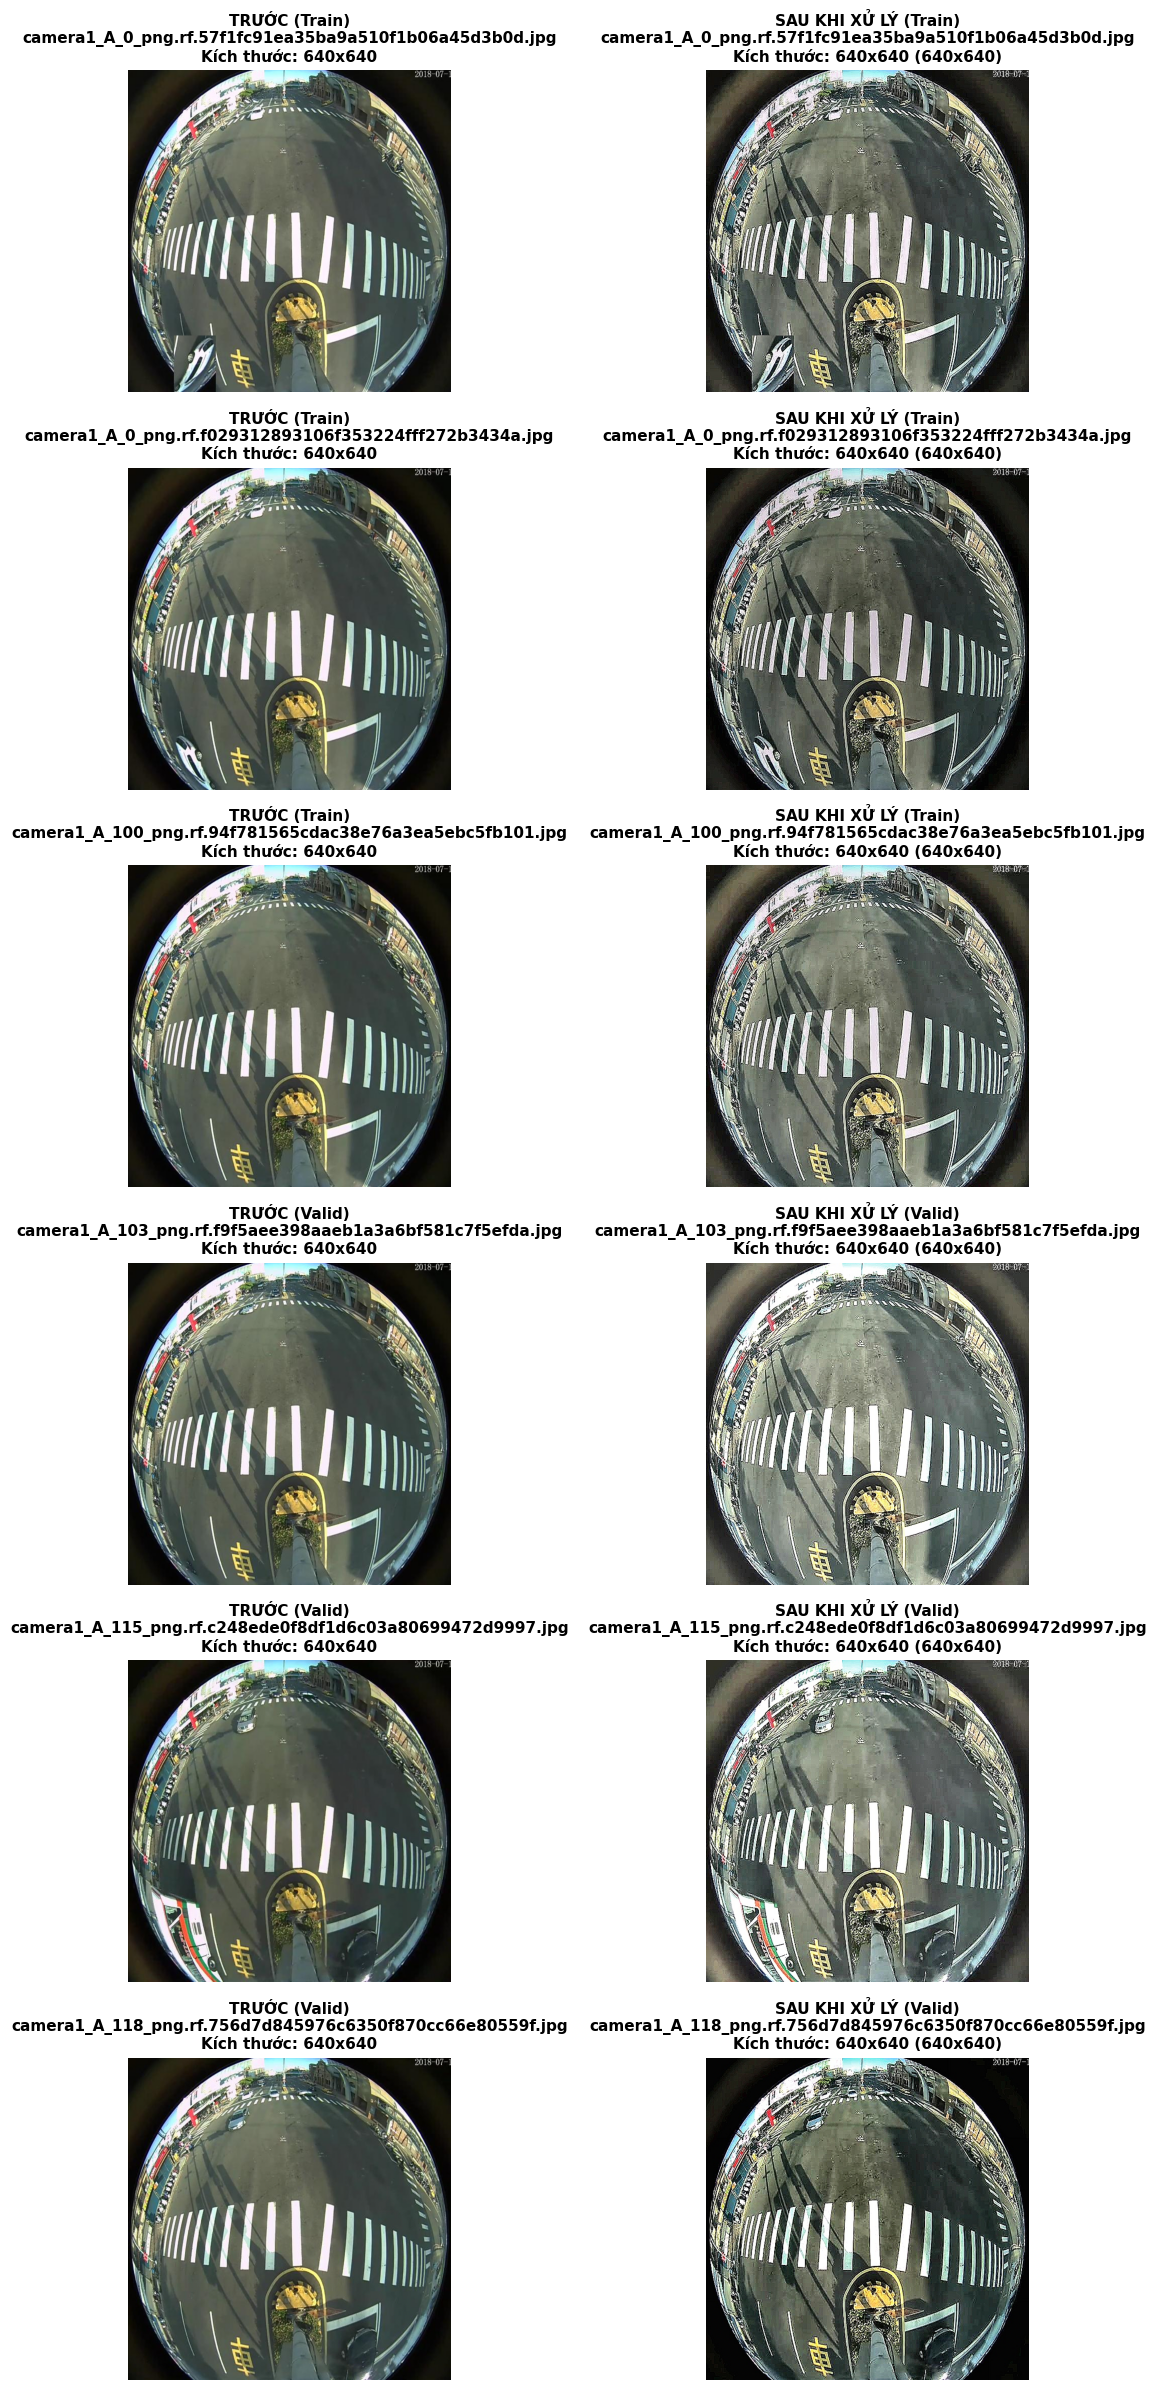


✅ Đã hiển thị 6 ảnh mẫu

💡 Các cải tiến đã áp dụng:
   1. ✅ Khử méo fisheye (undistort)
   2. ✅ Tăng tương phản (CLAHE)
   3. ✅ Tăng cường dữ liệu (Brightness/Contrast/Gamma)
   4. ✅ Làm sắc nét (Sharpen)
   5. ✅ Letterbox resize về 640x640
   6. ✅ Tự động phát hiện và sửa các vấn đề về ảnh



In [7]:
# ==============================================================================
# BƯỚC 3: XEM SO SÁNH ẢNH TRƯỚC VÀ SAU KHI XỬ LÝ
# ==============================================================================

# Magic command để hiển thị matplotlib trong notebook
%matplotlib inline

print("\n📊 Hiển thị so sánh ảnh trước và sau khi xử lý...")
print("=" * 70)

# Số lượng ảnh mẫu để hiển thị
num_samples = 6  # 3 từ train, 3 từ valid

try:
    import matplotlib.pyplot as plt
    from IPython.display import display
    
    # Lấy ảnh mẫu từ train set
    train_original_files = glob.glob(os.path.join(train_images_dir, '*.jpg'))[:3]
    train_processed_dir = os.path.join(processed_train_dir, 'images')
    
    # Lấy ảnh mẫu từ valid set
    valid_original_files = glob.glob(os.path.join(valid_images_dir, '*.jpg'))[:3]
    valid_processed_dir = os.path.join(processed_valid_dir, 'images')
    
    all_samples = []
    
    # Thêm samples từ train
    for orig_file in train_original_files:
        img_name = os.path.basename(orig_file)
        proc_file = os.path.join(train_processed_dir, img_name)
        if os.path.exists(proc_file):
            all_samples.append(('Train', orig_file, proc_file))
    
    # Thêm samples từ valid
    for orig_file in valid_original_files:
        img_name = os.path.basename(orig_file)
        proc_file = os.path.join(valid_processed_dir, img_name)
        if os.path.exists(proc_file):
            all_samples.append(('Valid', orig_file, proc_file))
    
    if all_samples:
        print(f"✅ Tìm thấy {len(all_samples)} ảnh mẫu để hiển thị\n")
        
        # Tạo figure với grid layout
        n_samples = min(len(all_samples), num_samples)
        fig, axes = plt.subplots(n_samples, 2, figsize=(14, 4 * n_samples))
        
        # Đảm bảo axes là 2D array
        if n_samples == 1:
            axes = axes.reshape(1, -1)
        
        for idx, (split_name, orig_path, proc_path) in enumerate(all_samples[:num_samples]):
            try:
                # Đọc ảnh
                orig_img = cv2.imread(orig_path)
                proc_img = cv2.imread(proc_path)
                
                if orig_img is None or proc_img is None:
                    continue
                
                # Chuyển BGR sang RGB cho matplotlib
                orig_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
                proc_rgb = cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB)
                
                # Hiển thị ảnh gốc
                axes[idx, 0].imshow(orig_rgb)
                axes[idx, 0].set_title(
                    f'TRƯỚC ({split_name})\n'
                    f'{os.path.basename(orig_path)}\n'
                    f'Kích thước: {orig_img.shape[1]}x{orig_img.shape[0]}',
                    fontsize=11, fontweight='bold'
                )
                axes[idx, 0].axis('off')
                
                # Hiển thị ảnh đã xử lý
                axes[idx, 1].imshow(proc_rgb)
                axes[idx, 1].set_title(
                    f'SAU KHI XỬ LÝ ({split_name})\n'
                    f'{os.path.basename(proc_path)}\n'
                    f'Kích thước: {proc_img.shape[1]}x{proc_img.shape[0]} (640x640)',
                    fontsize=11, fontweight='bold'
                )
                axes[idx, 1].axis('off')
                
            except Exception as e:
                print(f"⚠️ Lỗi khi hiển thị ảnh {orig_path}: {e}")
                continue
        
        plt.tight_layout()
        
        # Hiển thị figure trong notebook
        display(fig)
        plt.close(fig)  # Đóng figure để giải phóng memory
        
        print(f"\n✅ Đã hiển thị {n_samples} ảnh mẫu")
        print("\n💡 Các cải tiến đã áp dụng:")
        print("   1. ✅ Khử méo fisheye (undistort)")
        print("   2. ✅ Tăng tương phản (CLAHE)")
        print("   3. ✅ Tăng cường dữ liệu (Brightness/Contrast/Gamma)")
        print("   4. ✅ Làm sắc nét (Sharpen)")
        print("   5. ✅ Letterbox resize về 640x640")
        print("   6. ✅ Tự động phát hiện và sửa các vấn đề về ảnh")
        
    else:
        print("⚠️ Không tìm thấy ảnh đã xử lý để so sánh")
        print("   💡 Hãy đảm bảo đã chạy cell xử lý ảnh ở trên")
        
except ImportError:
    print("⚠️ Chưa cài matplotlib")
    print("   💡 Cài đặt: pip install matplotlib")
    print("\n📋 Thông tin về các bước xử lý đã áp dụng:")
    print("   1. Khử méo fisheye (undistort)")
    print("   2. Tăng tương phản (CLAHE)")
    print("   3. Tăng cường dữ liệu (Brightness/Contrast/Gamma)")
    print("   4. Làm sắc nét (Sharpen)")
    print("   5. Letterbox resize về 640x640")
except Exception as e:
    print(f"⚠️ Lỗi khi hiển thị ảnh: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 70)


## BƯỚC 4: TẠO DATA.YAML VỚI CLASS NAMES ĐÚNG

Tạo file data.yaml với class names đúng (bus, bikes, cars, pedestrian, truck) và đường dẫn train/val đúng.


In [8]:
# ==============================================================================
# BƯỚC 4: TẠO DATA.YAML VỚI CLASS NAMES ĐÚNG
# ==============================================================================

print("\n📝 Tạo data.yaml với cấu hình đúng...")
print("=" * 70)

# Tạo thư mục custom_train
custom_train_dir = os.path.join(dataset_path, 'custom_train_for_yolo')
os.makedirs(custom_train_dir, exist_ok=True)

# Tạo data.yaml với class names ĐÚNG
data_yaml_content = f"""
# Dataset configuration for YOLO training
# Generated by GiaiDoan4A_Preprocessing

# Paths (relative to this file or absolute)
train: {os.path.abspath(processed_train_dir)}/images
val: {os.path.abspath(processed_valid_dir)}/images

# Number of classes
nc: {num_classes}

# Class names (ĐÚNG tên, không phải số!)
names:
  - bus
  - bikes
  - cars
  - pedestrian
  - truck
"""

# Lưu data.yaml
data_yaml_path = os.path.join(custom_train_dir, 'data.yaml')
with open(data_yaml_path, 'w', encoding='utf-8') as f:
    f.write(data_yaml_content)

print(f"✅ Đã tạo data.yaml tại: {data_yaml_path}")
print(f"\n📋 Nội dung:")
print(data_yaml_content)

# Xác nhận
with open(data_yaml_path, 'r', encoding='utf-8') as f:
    loaded_yaml = yaml.safe_load(f)
    print(f"\n✅ Xác nhận class names: {loaded_yaml['names']}")
    print(f"✅ Train path: {loaded_yaml['train']}")
    print(f"✅ Val path: {loaded_yaml['val']}")

print("\n" + "=" * 70)
print("✅ HOÀN TẤT TIỀN XỬ LÝ!")
print(f"📁 Ảnh đã xử lý: {processed_train_dir} và {processed_valid_dir}")
print(f"📁 data.yaml: {data_yaml_path}")
print(f"💡 Tiếp theo: Chạy file GiaiDoan4B_TrainYOLO.ipynb để train model")
print("=" * 70)



📝 Tạo data.yaml với cấu hình đúng...
✅ Đã tạo data.yaml tại: d:\FishEyes_Yolo\complete_pipeline\Fisheye8K-7\custom_train_for_yolo\data.yaml

📋 Nội dung:

# Dataset configuration for YOLO training
# Generated by GiaiDoan4A_Preprocessing

# Paths (relative to this file or absolute)
train: d:\FishEyes_Yolo\complete_pipeline\Fisheye8K-7\processed_train/images
val: d:\FishEyes_Yolo\complete_pipeline\Fisheye8K-7\processed_valid/images

# Number of classes
nc: 5

# Class names (ĐÚNG tên, không phải số!)
names:
  - bus
  - bikes
  - cars
  - pedestrian
  - truck


✅ Xác nhận class names: ['bus', 'bikes', 'cars', 'pedestrian', 'truck']
✅ Train path: d:\FishEyes_Yolo\complete_pipeline\Fisheye8K-7\processed_train/images
✅ Val path: d:\FishEyes_Yolo\complete_pipeline\Fisheye8K-7\processed_valid/images

✅ HOÀN TẤT TIỀN XỬ LÝ!
📁 Ảnh đã xử lý: d:\FishEyes_Yolo\complete_pipeline\Fisheye8K-7\processed_train và d:\FishEyes_Yolo\complete_pipeline\Fisheye8K-7\processed_valid
📁 data.yaml: d:\FishEyes_Yolo